# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

In [2]:
import os
import urllib.request

# Define paths
data_dir = os.path.join("../05_src/data/fires")
os.makedirs(data_dir, exist_ok=True)

# UCI Forest Fires dataset URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/forest-fires/forestfires.csv"

# Local file path
local_file = os.path.join(data_dir, "forestfires.csv")

# Download if not already present
if not os.path.exists(local_file):
    print(f"Downloading dataset from {url}...")
    urllib.request.urlretrieve(url, local_file)
    print(f"Dataset saved to {local_file}")
else:
    print("Dataset already exists at:", local_file)


Dataset saved to ../05_src/data/fires\forestfires.csv


## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [1]:
# Load the libraries as required.
import pandas as pd

In [2]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [3]:
fires_dt.head()

,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


# Get X and Y

Create the features data frame and target data.

In [4]:
X = fires_dt.drop("area",axis=1)
y = fires_dt.area

# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [5]:
fires_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [6]:
numeric_features = X.drop(["temp", "wind"], axis=1).columns
print(numeric_features)

Index(['coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'rh',
       'rain'],
      dtype='object')


In [7]:
X.month.value_counts()

month
aug    184
sep    172
mar     54
jul     32
feb     20
jun     17
oct     15
apr      9
dec      9
jan      2
may      2
nov      1
Name: count, dtype: int64

In [8]:
X.day.value_counts()

day
sun    95
fri    85
sat    84
mon    74
tue    64
thu    61
wed    54
Name: count, dtype: int64

In [9]:
X.columns

Index(['coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi',
       'temp', 'rh', 'wind', 'rain'],
      dtype='object')

In [10]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define numeric & categorical feature lists
numeric_features = X.drop(["month", "day"], axis=1).columns
categorical_features = ["month", "day"]

# Create preproc1
preproc1 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),   # scale numeric vars
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)  # one-hot encode categorical vars
    ]
)

# Example: Apply transformation
X_transformed = preproc1.fit_transform(X)

print("Transformed feature matrix shape:", X_transformed.shape)


Transformed feature matrix shape: (517, 29)


### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [11]:
X.columns

Index(['coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi',
       'temp', 'rh', 'wind', 'rain'],
      dtype='object')

<Axes: >

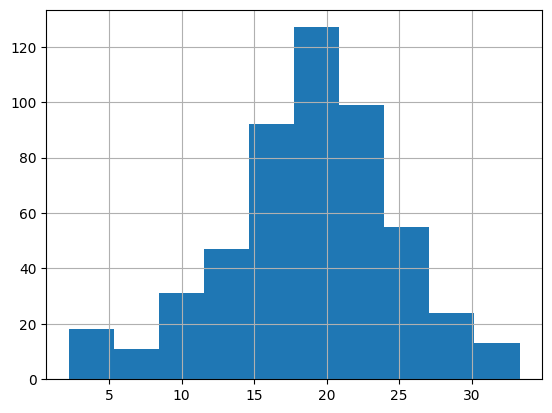

In [12]:
X.temp.hist()

<Axes: >

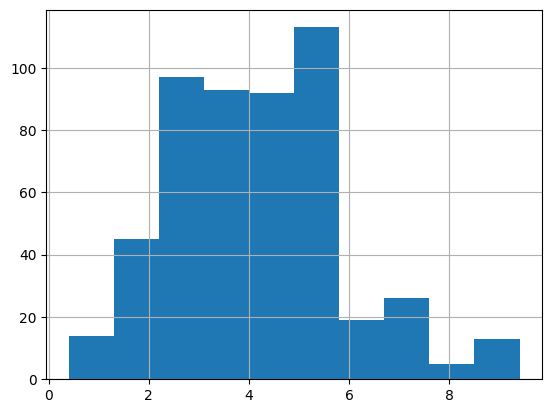

In [13]:
X.wind.hist()

Choose feature wind to be tranformed because the histogram plot a little bit skewed.

In [14]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, PowerTransformer
from sklearn.pipeline import Pipeline

# Define features
numeric_features = X.drop(["month", "day"], axis=1).columns
categorical_features = ["month", "day"]

# Special pipeline for wind: scale + Yeo-Johnson transform (handles negatives/zeros)
wind_transformer = Pipeline(steps=[
    ("scaler", RobustScaler()),
    ("power", PowerTransformer(method="yeo-johnson"))
])

# Preproc2: standard scale other numerics, power transform wind, one-hot encode categoricals
preproc2 = ColumnTransformer(
    transformers=[
        ("num_rest", StandardScaler(), [col for col in numeric_features if col != "wind"]),
        ("num_wind", wind_transformer, ["wind"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Apply transformation
X_transformed2 = preproc2.fit_transform(X)

print("Preproc2 transformed feature matrix shape:", X_transformed2.shape)

Preproc2 transformed feature matrix shape: (517, 29)


## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [15]:
# Pipeline A = preproc1 + baseline
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

# --- Baseline pipeline A ---
pipe_A = Pipeline(steps=[
    ("preprocessing", preproc1),   # from earlier
    ("regressor", LinearRegression())
])

# --- Cross-validation ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pipe_A, X, y, cv=cv, scoring="r2")  # or "neg_mean_squared_error"

print("Pipeline A (LinearRegression) R² scores:", scores)
print("Mean R²:", scores.mean())


Pipeline A (LinearRegression) R² scores: [ 0.0147685  -0.05861123 -0.40518935 -0.02116184 -0.52429355]
Mean R²: -0.19889749493600867


In [16]:
# Pipeline B = preproc2 + baseline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

# --- Baseline pipeline B ---
pipe_B = Pipeline(steps=[
    ("preprocessing", preproc2),   # from earlier
    ("regressor", LinearRegression())
])

# --- Cross-validation ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores_B = cross_val_score(pipe_B, X, y, cv=cv, scoring="r2")

print("Pipeline B (LinearRegression + preproc2) R² scores:", scores_B)
print("Mean R²:", scores_B.mean())


Pipeline B (LinearRegression + preproc2) R² scores: [ 0.01538956 -0.05757896 -0.41637855 -0.02049597 -0.52396096]
Mean R²: -0.20060497322184984


In [17]:
# Pipeline C = preproc1 + advanced model
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold

# --- Advanced pipeline C ---
pipe_C = Pipeline(steps=[
    ("preprocessing", preproc1),   
    ("regressor", RandomForestRegressor(random_state=42))
])

# --- Define hyperparameter grid ---
param_grid_C = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [None, 10, 20],
    "regressor__min_samples_split": [2, 5]
}

# --- Cross-validation setup ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# --- GridSearchCV ---
grid_C = GridSearchCV(
    estimator=pipe_C,
    param_grid=param_grid_C,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

grid_C.fit(X, y)

print("Best parameters (Pipeline C):", grid_C.best_params_)
print("Best R² score (Pipeline C):", grid_C.best_score_)


Best parameters (Pipeline C): {'regressor__max_depth': 10, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
Best R² score (Pipeline C): -0.9248111135163853


In [18]:
# Pipeline D = preproc2 + advanced model
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold

# --- Advanced pipeline D ---
pipe_D = Pipeline(steps=[
    ("preprocessing", preproc2),
    ("regressor", RandomForestRegressor(random_state=42))
])

# --- Define hyperparameter grid ---
param_grid_D = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [None, 10, 20],
    "regressor__min_samples_split": [2, 5]
}

# --- Cross-validation setup ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# --- GridSearchCV ---
grid_D = GridSearchCV(
    estimator=pipe_D,
    param_grid=param_grid_D,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# Fit the model
grid_D.fit(X, y)

print("Best parameters (Pipeline D):", grid_D.best_params_)
print("Best R² score (Pipeline D):", grid_D.best_score_)

    

Best parameters (Pipeline D): {'regressor__max_depth': 10, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
Best R² score (Pipeline D): -0.9319183961138311


# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [19]:
# Pipeline A
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import LinearRegression

param_grid_A = {
    "regressor__fit_intercept": [True, False],
    "regressor__positive": [True, False]  # enforce positive coefficients
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_A = GridSearchCV(pipe_A, param_grid=param_grid_A, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid_A.fit(X, y)

# Get actual RMSE
best_rmse_A = -grid_A.best_score_
print("Pipeline A best RMSE:", best_rmse_A)
print("Best hyperparameters:", grid_A.best_params_)


Pipeline A best RMSE: 55.12698376049607
Best hyperparameters: {'regressor__fit_intercept': False, 'regressor__positive': True}


In [20]:
# Pipeline B
param_grid_B = {
    "regressor__fit_intercept": [True, False],
    "regressor__positive": [True, False]
}

grid_B = GridSearchCV(pipe_B, param_grid=param_grid_B, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid_B.fit(X, y)

# Get actual RMSE
best_rmse_B = -grid_B.best_score_
print("Pipeline B best RMSE:", best_rmse_B)
print("Best hyperparameters:", grid_B.best_params_)

Pipeline B best RMSE: 55.130618815330266
Best hyperparameters: {'regressor__fit_intercept': False, 'regressor__positive': True}


In [21]:
# Pipeline C
from sklearn.ensemble import RandomForestRegressor

param_grid_C = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [None, 10]  # 2 × 2 = 4 combinations
}

grid_C = GridSearchCV(pipe_C, param_grid=param_grid_C, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid_C.fit(X, y)

# Get actual RMSE
best_rmse_C = -grid_C.best_score_
print("Pipeline C best RMSE:", best_rmse_C)
print("Best hyperparameters:", grid_C.best_params_)


Pipeline C best RMSE: 64.71406319573111
Best hyperparameters: {'regressor__max_depth': 10, 'regressor__n_estimators': 200}


In [22]:
# Pipeline D
param_grid_D = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [None, 10]
}

grid_D = GridSearchCV(pipe_D, param_grid=param_grid_D, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid_D.fit(X, y)

# Get actual RMSE
best_rmse_D = -grid_D.best_score_
print("Pipeline D best RMSE:", best_rmse_D)
print("Best hyperparameters:", grid_D.best_params_)


Pipeline D best RMSE: 64.79770328561668
Best hyperparameters: {'regressor__max_depth': 10, 'regressor__n_estimators': 200}


In [23]:
import pandas as pd

# Create a summary dictionary
summary = {
    "Pipeline": ["A", "B", "C", "D"],
    "Preprocessing": ["preproc1", "preproc2", "preproc1", "preproc2"],
    "Model": ["LinearRegression", "LinearRegression", "RandomForest", "RandomForest"],
    "Best RMSE": [
        best_rmse_A,
        best_rmse_B,
        best_rmse_C,
        best_rmse_D
    ],
    "Best Hyperparameters": [
        grid_A.best_params_,
        grid_B.best_params_,
        grid_C.best_params_,
        grid_D.best_params_
    ]
}

# Convert to DataFrame
summary_df = pd.DataFrame(summary)

# Display
print(summary_df)


  Pipeline Preprocessing             Model  Best RMSE  \
0        A      preproc1  LinearRegression  55.126984   
1        B      preproc2  LinearRegression  55.130619   
2        C      preproc1      RandomForest  64.714063   
3        D      preproc2      RandomForest  64.797703   

                                Best Hyperparameters  
0  {'regressor__fit_intercept': False, 'regressor...  
1  {'regressor__fit_intercept': False, 'regressor...  
2  {'regressor__max_depth': 10, 'regressor__n_est...  
3  {'regressor__max_depth': 10, 'regressor__n_est...  


# Evaluate

+ Which model has the best performance?

Model with pipeline A has the best performance based on RMSE

# Export

+ Save the best performing model to a pickle file.

In [24]:
import pickle
import os

best_pipeline_model = grid_A.best_estimator_
# Make sure directory exists
os.makedirs("../05_src/data/fires/", exist_ok=True)

# Path to the pickle file (must include filename)
model_path = "../05_src/data/fires/best_model.pkl"

# Save the fitted pipeline
with open(model_path, "wb") as f:
    pickle.dump(best_pipeline_model, f)

print(f"Best performing model saved to: {model_path}")


Best performing model saved to: ../05_src/data/fires/best_model.pkl


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [25]:
import shap
import pandas as pd
import numpy as np

# Assume best_pipeline_model = grid_D.best_estimator_ (fitted)
# Split your data into train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Extract the trained regressor from the pipeline
regressor = best_pipeline_model.named_steps["regressor"]

# Preprocessing step
preprocessor = best_pipeline_model.named_steps["preprocessing"]

# Transform training data
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)


In [26]:
import shap

# Create a masker for background dataset
masker = shap.maskers.Independent(X_train_transformed)

# Linear explainer
explainer = shap.LinearExplainer(regressor, masker=masker)

# SHAP values for test data
shap_values = explainer(X_test_transformed)


In [28]:
import joblib
best_model = joblib.load("../05_src/data/fires/best_model.pkl")


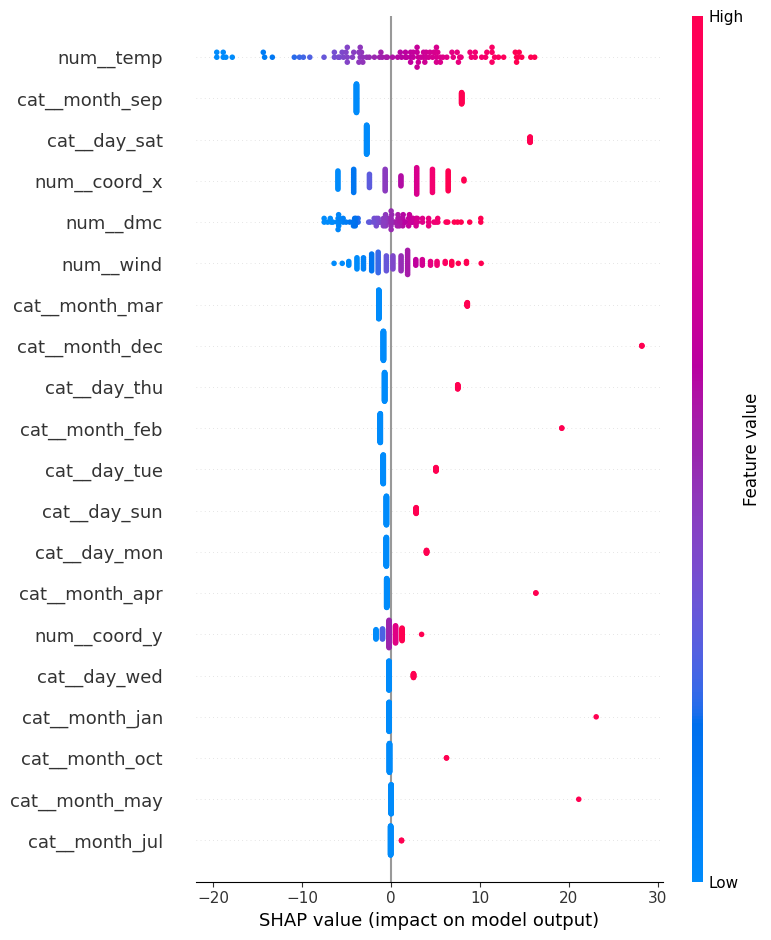

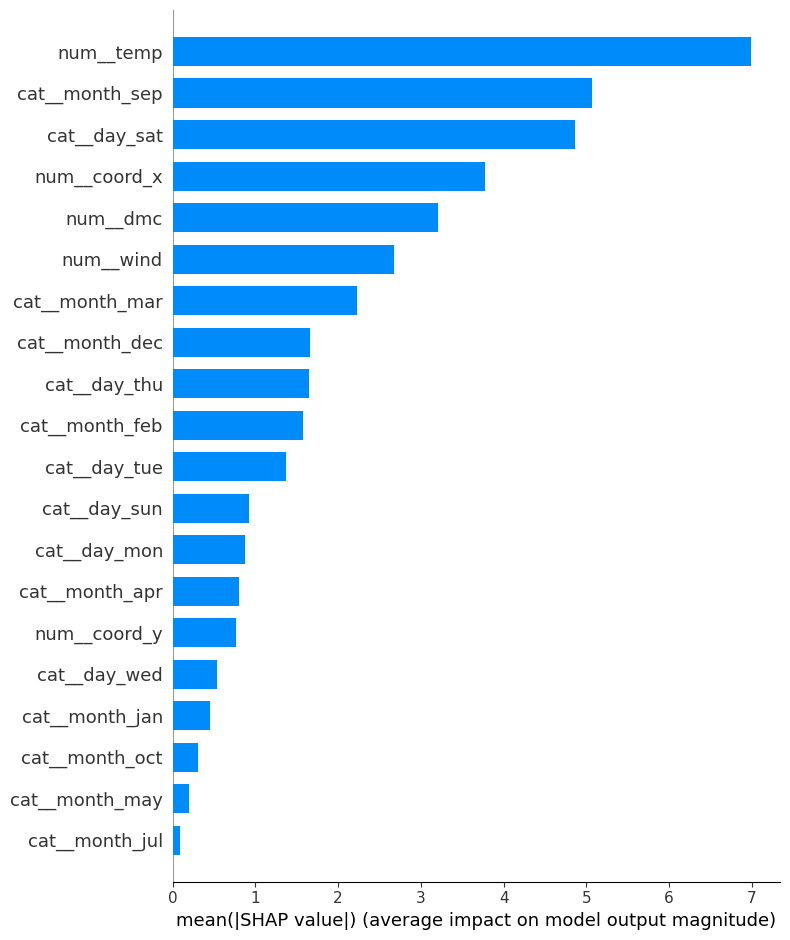


Feature Importance (Mean |SHAP| Values):
num__temp: 6.9888
cat__month_sep: 5.0667
cat__day_sat: 4.8629
num__coord_x: 3.7754
num__dmc: 3.2019
num__wind: 2.6731
cat__month_mar: 2.2219
cat__month_dec: 1.6610
cat__day_thu: 1.6494
cat__month_feb: 1.5711
cat__day_tue: 1.3681
cat__day_sun: 0.9284
cat__day_mon: 0.8729
cat__month_apr: 0.8069
num__coord_y: 0.7704
cat__day_wed: 0.5318
cat__month_jan: 0.4526
cat__month_oct: 0.3085
cat__month_may: 0.2030
cat__month_jul: 0.0931
num__ffmc: 0.0000
num__dc: 0.0000
num__isi: 0.0000
num__rh: 0.0000
num__rain: 0.0000
cat__month_aug: 0.0000
cat__month_jun: 0.0000
cat__month_nov: 0.0000
cat__day_fri: 0.0000

Candidate features for removal: ['num__ffmc', 'num__dc', 'num__isi', 'num__rh', 'num__rain', 'cat__month_aug', 'cat__month_jun', 'cat__month_nov', 'cat__day_fri']


In [29]:
import shap
import matplotlib.pyplot as plt

# --- Step 1: Extract regressor and preprocessing ---
regressor = best_model.named_steps["regressor"]
preprocessor = best_model.named_steps["preprocessing"]

# Transform train & test data
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Get feature names after preprocessing (scaling + one-hot encoding)
feature_names = preprocessor.get_feature_names_out()

# --- Step 2: Build SHAP explainer for LinearRegression ---
explainer = shap.LinearExplainer(regressor, X_train_transformed)

# Compute SHAP values for test set
shap_values = explainer.shap_values(X_test_transformed)

# --- Step 3: Local explanation (one observation) ---
obs_index = 0  # pick first test example (you can change this)
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[obs_index],
    X_test_transformed[obs_index],
    feature_names=feature_names
)

# --- Step 4: Global explanation (overall importance) ---
# Summary plot (beeswarm)
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

# Bar plot for feature importance
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar")

# --- Step 5: Decide on feature removal ---
# You can check which features have near-zero mean absolute SHAP value
importance = np.abs(shap_values).mean(axis=0)
feature_importance = sorted(zip(feature_names, importance), key=lambda x: x[1], reverse=True)

print("\nFeature Importance (Mean |SHAP| Values):")
for feat, imp in feature_importance:
    print(f"{feat}: {imp:.4f}")

# Suggest features for removal (very low importance)
low_importance = [feat for feat, imp in feature_importance if imp < 0.01]
print("\nCandidate features for removal:", low_importance)


 The features that need to be removed are  ['num__ffmc', 'num__dc', 'num__isi', 'num__rh', 'num__rain']. The categorical features can not be removed separately, it must be removed as a whole.

*(Answer here.)*

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.